# Sensor, Tree & Road Plots
8 individual maps — one per sensor — showing:
- 🔵 **Sensor** at the centre
- 🟩 🟫 **Trees** (deciduous vs evergreen) nearby
- 🟠 **Road segments** linked to that sensor

**How to use:**
1. Upload your three files when prompted (or place them in the session).
2. Run all cells (`Runtime → Run all`).
3. Optionally adjust `BUFFER_M` to change the neighbourhood radius.

In [4]:
!pip install geopandas matplotlib contextily shapely --quiet

from google.colab import drive
drive.mount('/content/drive')

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import contextily as ctx
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
sensors  = gpd.read_file('/content/drive/MyDrive/sensors.geojson')
segments = gpd.read_file('/content/drive/MyDrive/segments.geojson')
trees = pd.read_csv('/content/drive/MyDrive/VOLUME_DATASET.csv')

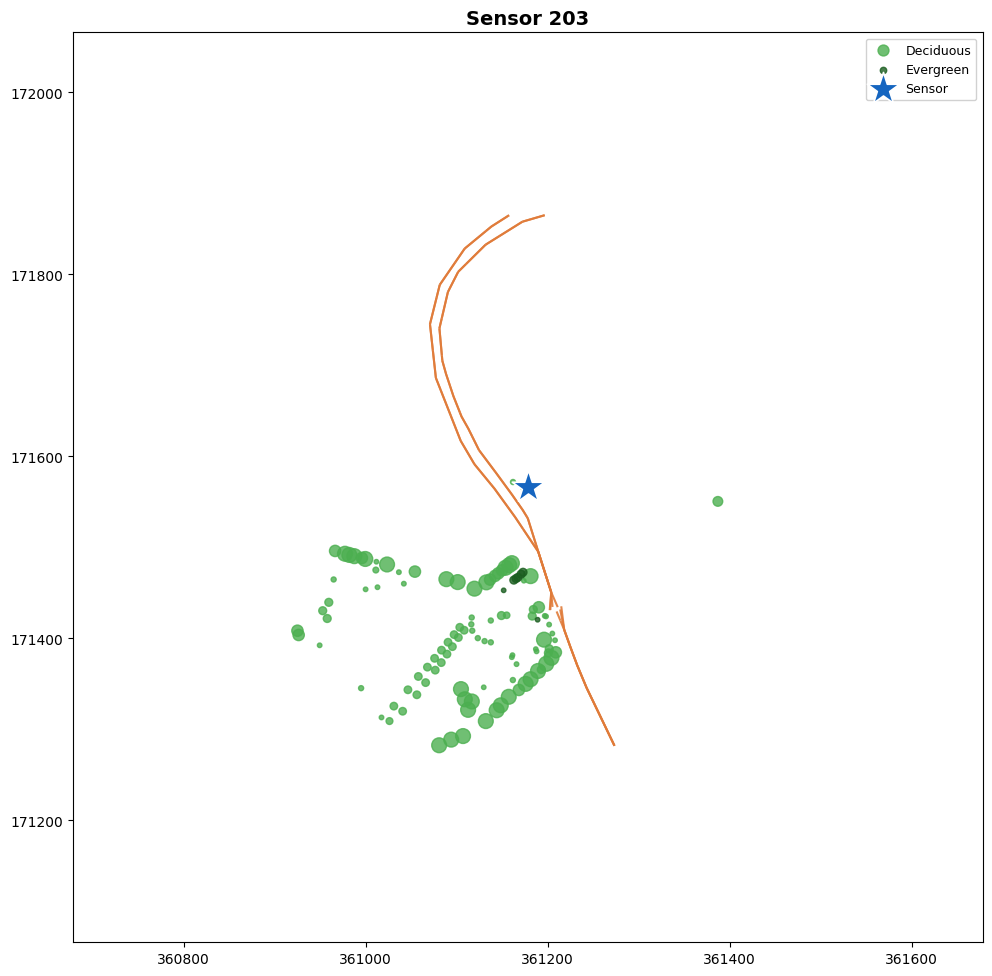

✓ Sensor 203 — 102 road segments, 111 trees


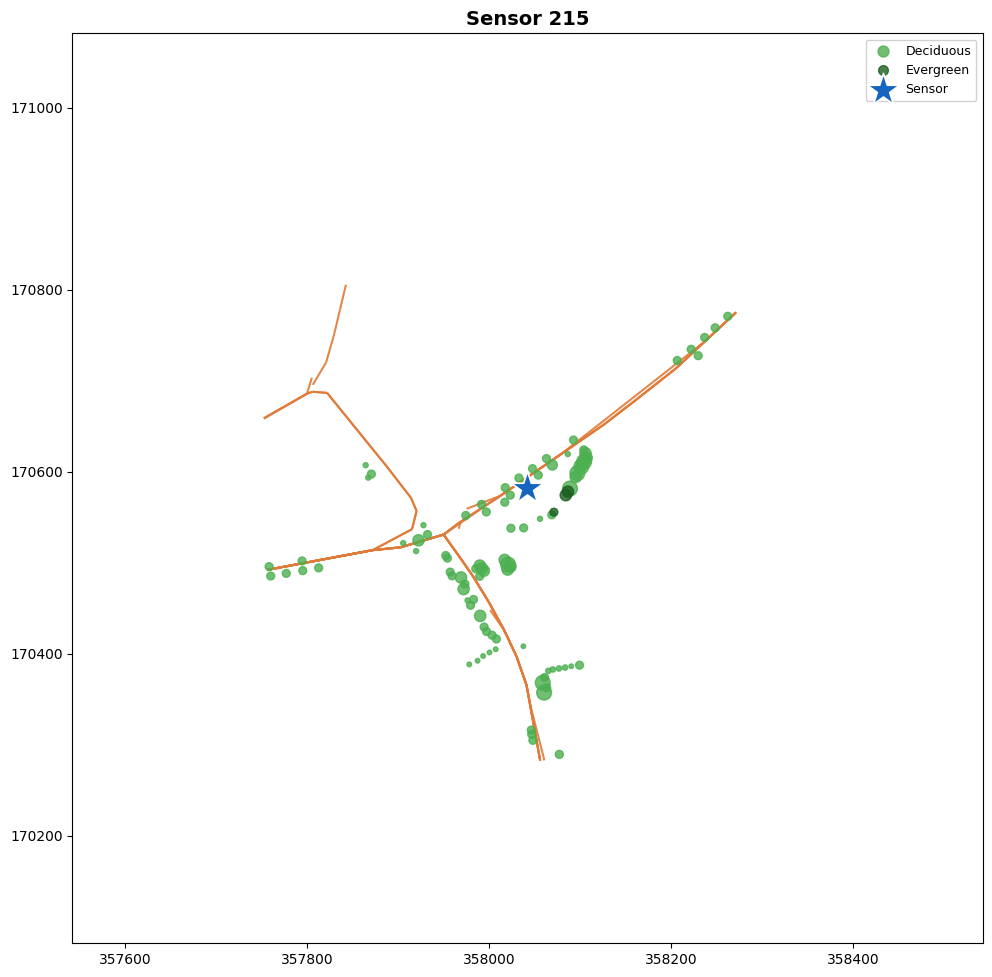

✓ Sensor 215 — 187 road segments, 95 trees


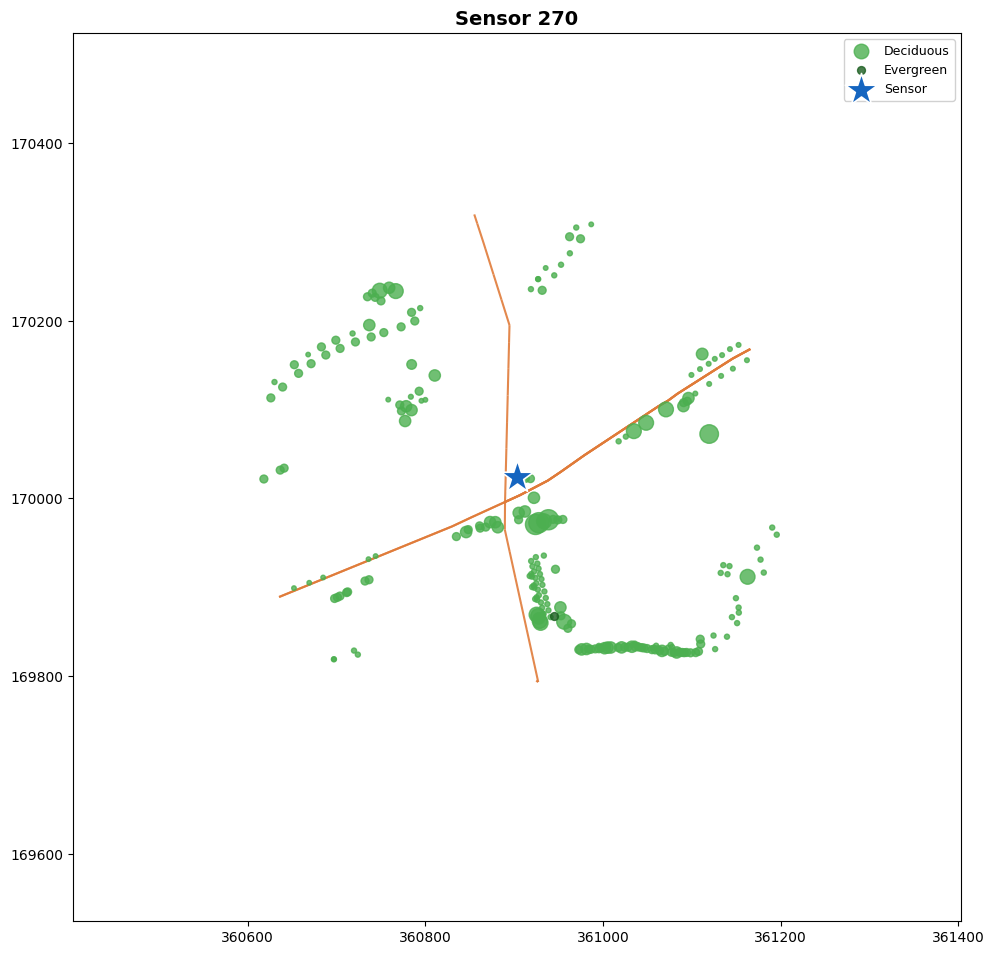

✓ Sensor 270 — 85 road segments, 225 trees


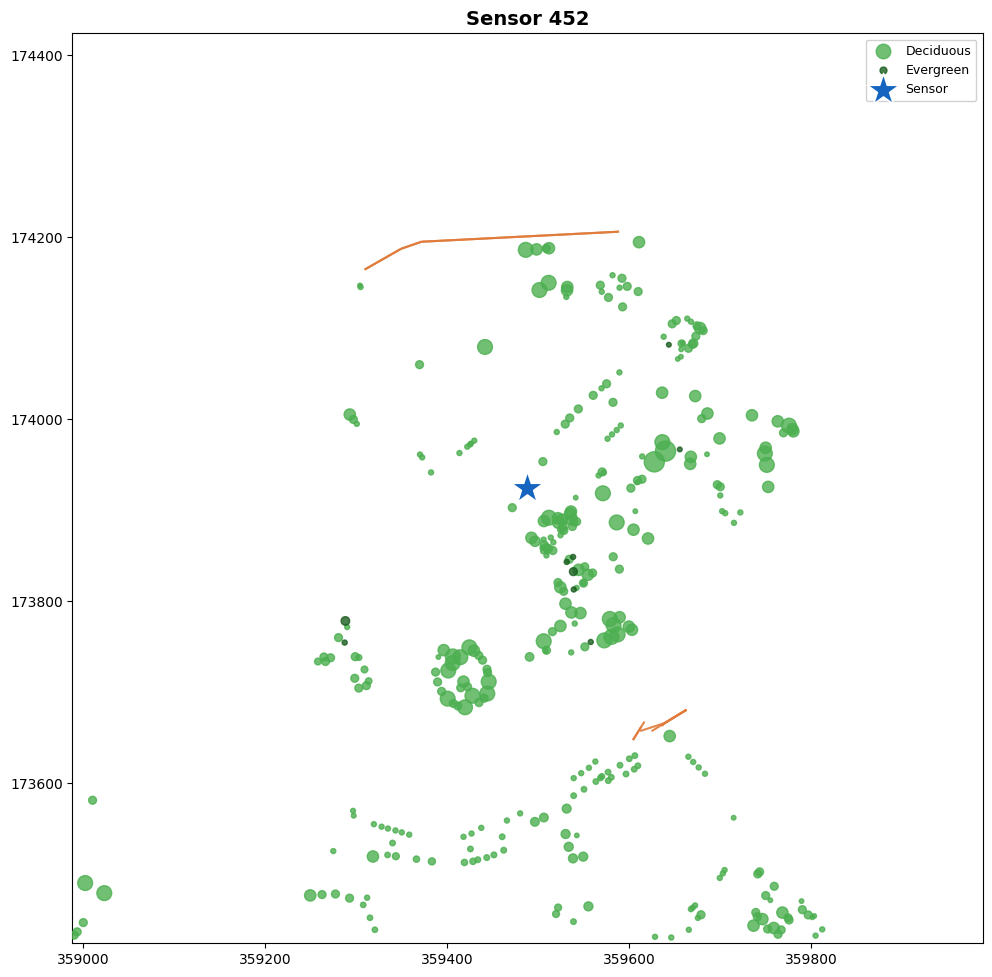

✓ Sensor 452 — 34 road segments, 331 trees


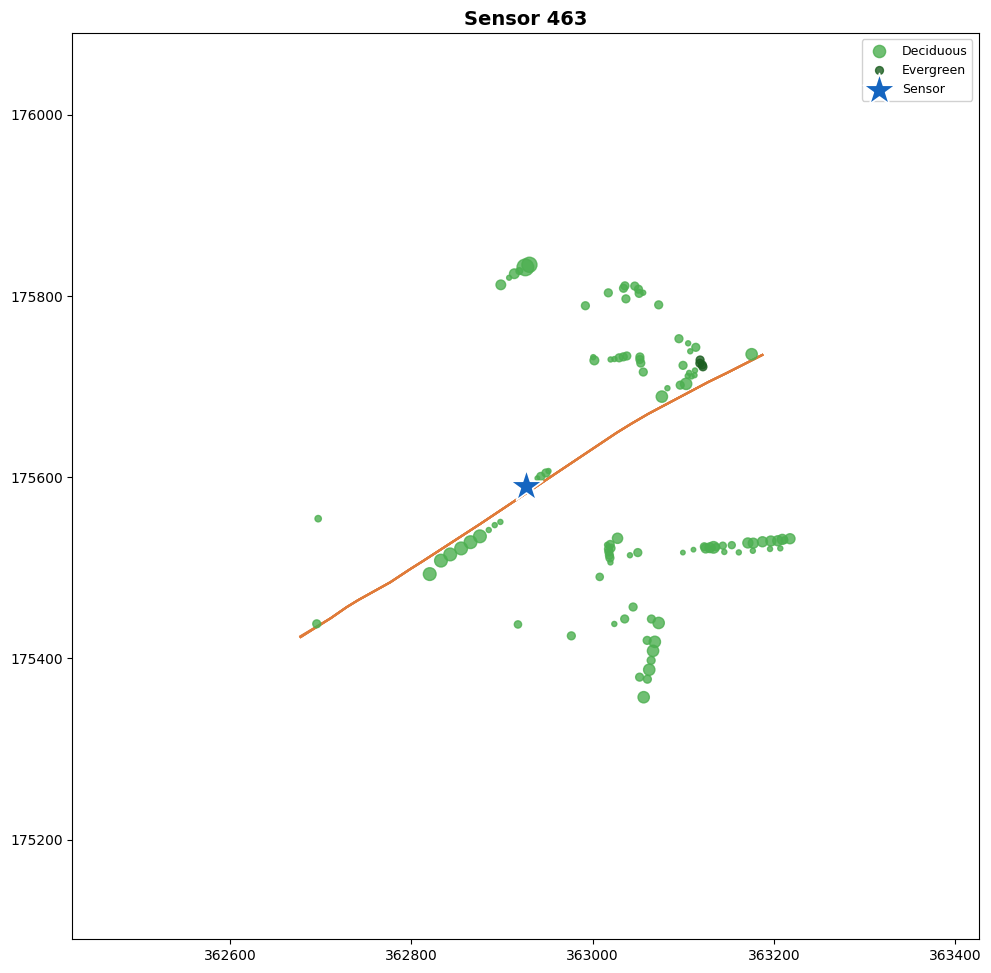

✓ Sensor 463 — 120 road segments, 112 trees


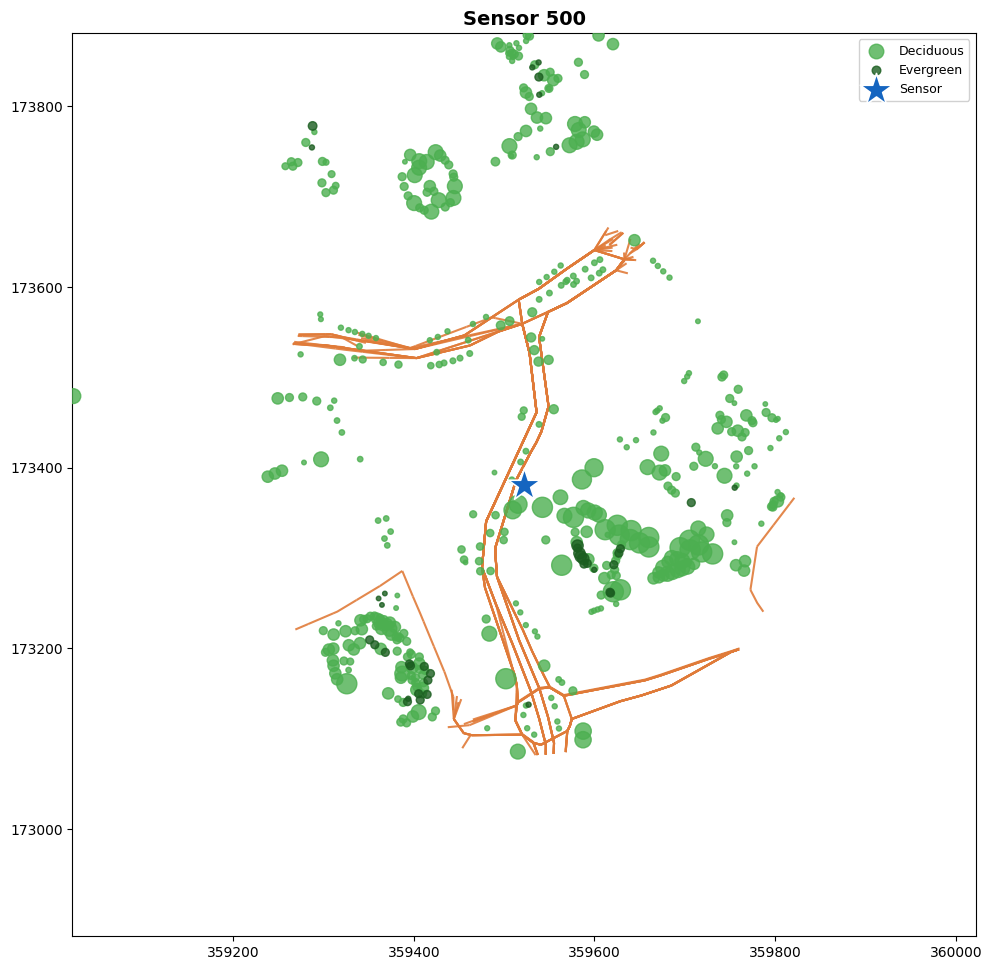

✓ Sensor 500 — 963 road segments, 473 trees


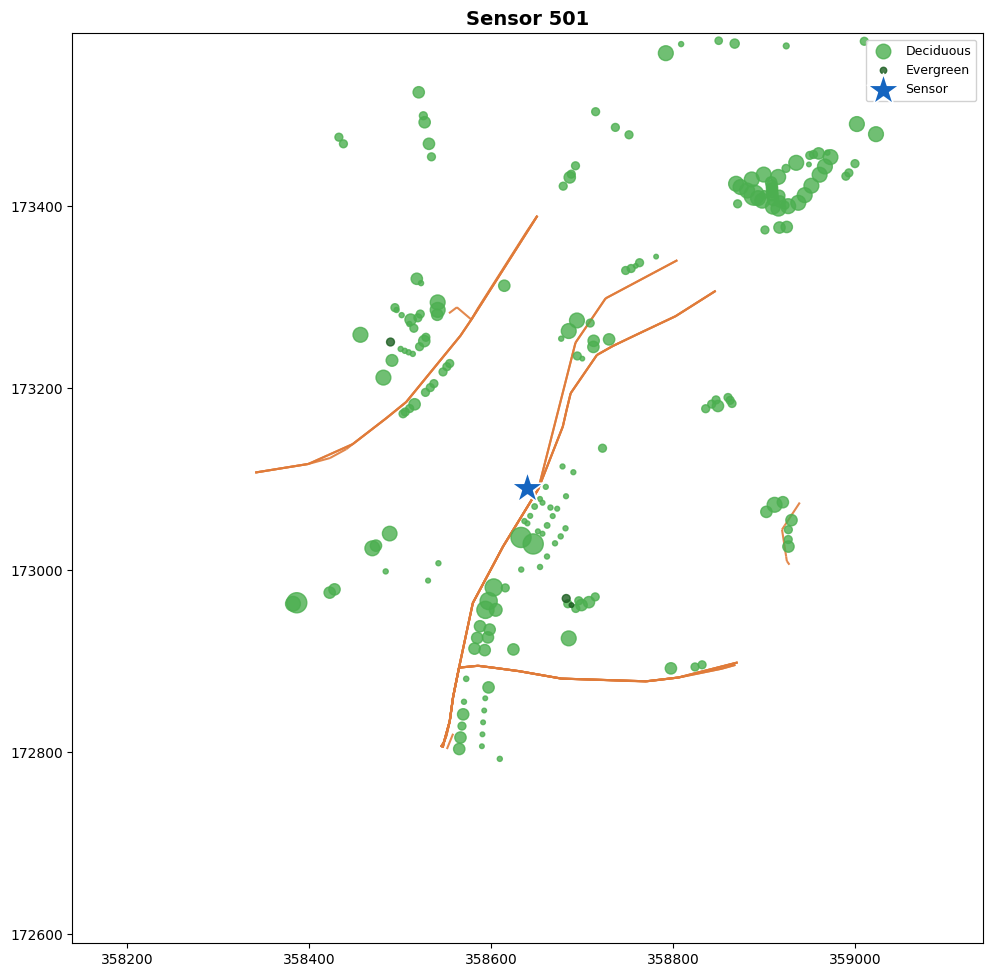

✓ Sensor 501 — 257 road segments, 199 trees


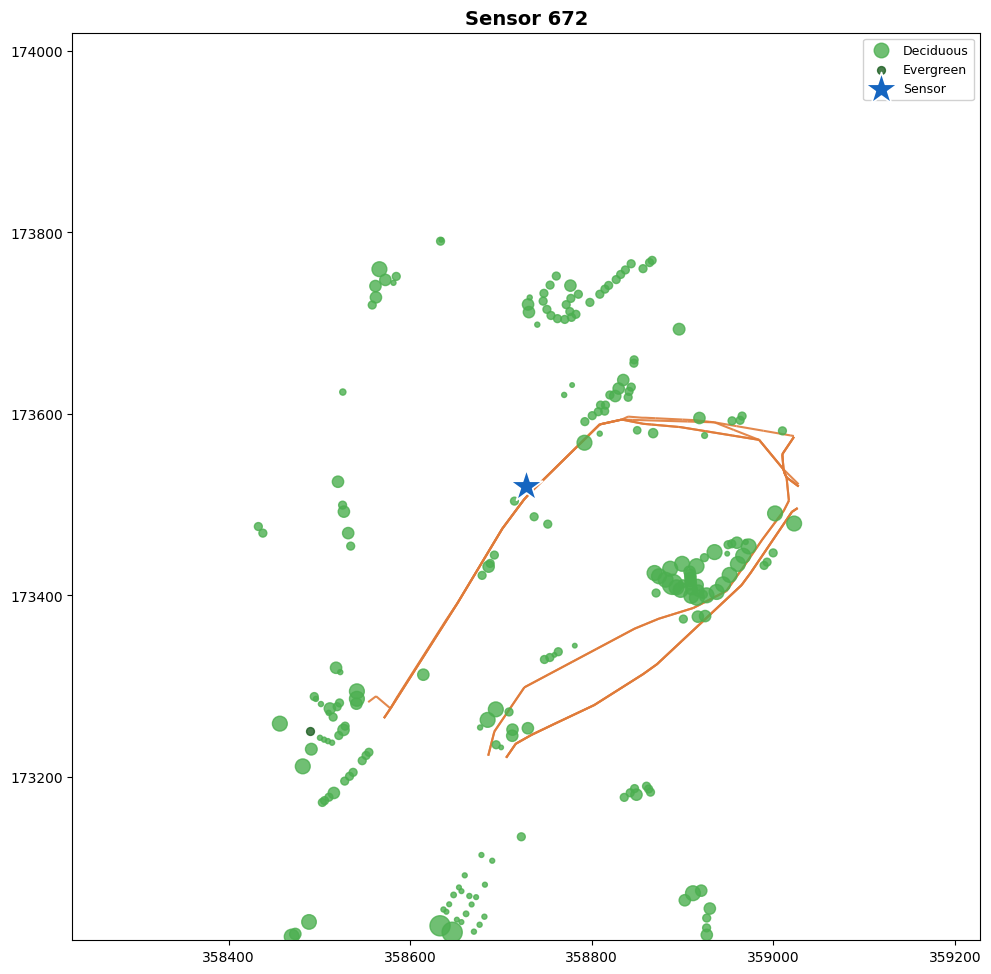

✓ Sensor 672 — 196 road segments, 214 trees


In [14]:
vol = trees['CROWN_AREA_COMPLETE']
trees['marker_size'] = 10 + (vol - vol.min()) / (vol.max() - vol.min()) * 200

# ── Plot ───────────────────────────────────────────────────────────────────────
BUFFER   = 500
DEC_COL  = '#4CAF50'
EVG_COL  = '#1B5E20'
ROAD_COL = '#E07B39'
SEN_COL  = '#1565C0'

for _, sensor in sensors.iterrows():
    sx, sy  = sensor.geometry.x, sensor.geometry.y
    site_id = sensor['SITE_ID']

    segs  = segments[segments['SITE_ID'] == site_id]
    nearby = trees[
        (trees['X'] >= sx - BUFFER) & (trees['X'] <= sx + BUFFER) &
        (trees['Y'] >= sy - BUFFER) & (trees['Y'] <= sy + BUFFER)
    ]
    dec = nearby[nearby['tree_group'] == 'deciduous']
    evg = nearby[nearby['tree_group'] == 'evergreen']

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(sx - BUFFER, sx + BUFFER)
    ax.set_ylim(sy - BUFFER, sy + BUFFER)
    #ax.set_facecolor('#f0f0f0')
    #fig.patch.set_facecolor('#f0f0f0')

    # Roads
    segs.plot(ax=ax, color=ROAD_COL, linewidth=1.5, alpha=0.9, zorder=2)

    # Trees
    ax.scatter(dec['X'], dec['Y'], s=dec['marker_size'], color=DEC_COL, alpha=0.8, zorder=3, label='Deciduous')
    ax.scatter(evg['X'], evg['Y'], s=evg['marker_size'], color=EVG_COL, alpha=0.8, zorder=3, label='Evergreen')

    # Sensor
    ax.scatter(sx, sy, s=600, marker='*', color=SEN_COL, edgecolors='white', linewidths=1.2, zorder=5, label='Sensor')

    ax.set_title(f'Sensor {site_id}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()
    print(f'✓ Sensor {site_id} — {len(segs)} road segments, {len(nearby)} trees')